# 🔧 Thực hành: Chẩn đoán hư hỏng ổ lăn bằng SVM, Random Forest & SHAP
## Bộ dữ liệu CWRU Bearing Dataset

**Mục tiêu:**
- Xây dựng pipeline hoàn chỉnh: Tín hiệu rung → Trích đặc trưng → Huấn luyện SVM & Random Forest → Đánh giá → Giải thích bằng SHAP
- Dành cho kỹ sư bảo trì & vận hành nhà máy

**Yêu cầu:** Đặt thư mục dữ liệu CWRU (.mat files) theo cấu trúc:
```
./CWRU Data/
├── 0HP/  (Normal, IR_007, OR_007@6, B_007, ...)
├── 1HP/
├── 2HP/
└── 3HP/
```

## 1. Cài đặt & Import thư viện

Cài đặt các thư viện cần thiết (chạy 1 lần):
```bash
pip install numpy scipy pandas matplotlib seaborn scikit-learn shap
```

In [18]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.stats as sp_stats
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram as scipy_spectrogram

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

import shap
import warnings
warnings.filterwarnings('ignore')

# === CẤU HÌNH ===
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Đường dẫn đến thư mục dữ liệu CWRU - THAY ĐỔI NẾU CẦN
DATA_ROOT = "./CWRU_Tutorials/data"

# Tham số xử lý tín hiệu
SAMPLE_RATE = 12000      # Tần số lấy mẫu (Hz)
WINDOW_SIZE = 2048        # Độ dài cửa sổ (số mẫu)
OVERLAP = 0.5             # Tỷ lệ chồng lấp giữa các cửa sổ

# Matplotlib config
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("✅ Import thành công. Sẵn sàng thực hành!")


✅ Import thành công. Sẵn sàng thực hành!


## 2. Đọc & chuẩn bị dữ liệu CWRU

### 2.1. Hàm đọc file .mat và trích kênh DE (Drive End)

Mỗi file `.mat` chứa tín hiệu gia tốc rung. Ta sẽ:
1. Đọc file bằng `scipy.io.loadmat()`
2. Tìm biến có tên chứa `DE_time` (kênh Drive End)
3. Trả về mảng 1D (tín hiệu rung theo thời gian)

In [19]:
def extract_de_signal(mat_data):
    """Trích tín hiệu kênh DE (Drive End) từ dữ liệu .mat.
    
    Kênh DE gần ổ lăn nhất nên cho tín hiệu rõ ràng nhất về hư hỏng.
    """
    for key in mat_data.keys():
        if 'DE_time' in key:
            return np.squeeze(mat_data[key])
    # Fallback: lấy mảng số đầu tiên nếu không tìm thấy DE_time
    for key, val in mat_data.items():
        if not key.startswith('__') and isinstance(val, np.ndarray):
            if val.ndim <= 2:
                return np.squeeze(val)
    raise ValueError("Không tìm thấy tín hiệu phù hợp trong file .mat")


def parse_label_from_filename(filename):
    """Xác định loại lỗi từ tên file.
    
    Quy ước tên file CWRU:
    - Normal.npy hoặc normal_*.mat → 'Normal'
    - IR_007.npy → 'IR' (Inner Race fault)
    - OR_007@6.npy → 'OR' (Outer Race fault) 
    - B_007.npy → 'B' (Ball fault)
    """
    base = os.path.basename(filename).replace('.npy', '').replace('_de', '').lower()
    if 'normal' in base:
        return 'Normal'
    elif base.startswith('ir'):
        return 'IR'
    elif base.startswith('or'):
        return 'OR'
    elif base.startswith('b'):
        return 'B'
    return 'Unknown'

print("✅ Hàm đọc dữ liệu đã sẵn sàng.")


✅ Hàm đọc dữ liệu đã sẵn sàng.


### 2.2. Cắt tín hiệu thành các segment (cửa sổ)

Tín hiệu rung dài hàng trăm nghìn mẫu → cần cắt thành nhiều đoạn ngắn (segment).

- **Window size = 2048 mẫu** ≈ 0.17 giây ở 12 kHz → chứa ~5 vòng quay
- **Overlap = 50%** → tăng số mẫu huấn luyện, không bỏ sót thông tin

In [20]:
def segment_signal(signal, window_size=WINDOW_SIZE, overlap=OVERLAP):
    """Cắt tín hiệu 1D thành nhiều segment bằng cửa sổ trượt.
    
    Args:
        signal: mảng 1D chứa tín hiệu rung
        window_size: số mẫu mỗi segment
        overlap: tỷ lệ chồng lấp (0.0 đến 1.0)
    
    Returns:
        segments: mảng 2D (num_segments, window_size)
    """
    step = int(window_size * (1 - overlap))  # Bước nhảy giữa các cửa sổ
    num_segments = (len(signal) - window_size) // step + 1
    
    if num_segments <= 0:
        return np.empty((0, window_size))
    
    segments = np.array([
        signal[i * step : i * step + window_size]
        for i in range(num_segments)
    ])
    return segments

print(f"✅ Hàm cắt segment: window={WINDOW_SIZE}, overlap={OVERLAP}")

✅ Hàm cắt segment: window=2048, overlap=0.5


### 2.3. Đọc toàn bộ dữ liệu CWRU

Duyệt qua tất cả thư mục (0HP → 3HP), đọc từng file `.mat`, cắt segment, gán nhãn.

In [21]:
def load_cwru_data(data_root=DATA_ROOT, domains=['0HP','1HP','2HP','3HP']):
    """Đọc toàn bộ dữ liệu CWRU và cắt thành segments.
    
    Returns:
        all_segments: list các mảng 1D (mỗi mảng là 1 segment)
        all_labels: list nhãn tương ứng ('Normal','IR','OR','B')
        all_meta: list dict chứa thông tin bổ sung (file, domain, ...)
    """
    all_segments = []
    all_labels = []
    all_meta = []
    
    for domain in domains:
        domain_path = os.path.join(data_root, domain)
        if not os.path.exists(domain_path):
            print(f"⚠️  Không tìm thấy thư mục: {domain_path}")
            continue
            
        mat_files = glob.glob(os.path.join(domain_path, "*.npy"))
        print(f"\n📂 {domain}: tìm thấy {len(mat_files)} file .npy")
        
        for fpath in sorted(mat_files):
            fname = os.path.basename(fpath)
            label = parse_label_from_filename(fname)
            
            if label == 'Unknown':
                print(f"   ⏭️  Bỏ qua file không nhận dạng được: {fname}")
                continue
            
            try:
                signal = np.load(fpath)
                
                segments = segment_signal(signal)
                
                all_segments.extend(segments)
                all_labels.extend([label] * len(segments))
                all_meta.extend([{'file': fname, 'domain': domain}] * len(segments))
                
                print(f"   ✅ {fname}: {len(signal)} mẫu → {len(segments)} segments [{label}]")
            except Exception as e:
                print(f"   ❌ Lỗi đọc {fname}: {e}")
    
    return np.array(all_segments), np.array(all_labels), all_meta

# === THỰC THI ===
print("="*60)
print("ĐANG ĐỌC DỮ LIỆU CWRU...")
print("="*60)
X_raw, y_raw, meta = load_cwru_data()
print(f"\n{'='*60}")
print(f"TỔNG KẾT: {len(X_raw)} segments, {len(np.unique(y_raw))} lớp")
print(f"Phân bố lớp:")
for cls in np.unique(y_raw):
    print(f"  {cls}: {np.sum(y_raw == cls)} segments")


ĐANG ĐỌC DỮ LIỆU CWRU...

📂 0HP: tìm thấy 14 file .mat
   ✅ B_007.mat: 244739 mẫu → 238 segments [B]
   ✅ B_014.mat: 249146 mẫu → 242 segments [B]
   ✅ B_021.mat: 243938 mẫu → 237 segments [B]
   ✅ IR_007.mat: 243938 mẫu → 237 segments [IR]
   ✅ IR_014.mat: 63788 mẫu → 61 segments [IR]
   ✅ IR_021.mat: 244339 mẫu → 237 segments [IR]
   ✅ Normal.mat: 243938 mẫu → 237 segments [Normal]
   ✅ OR_007@12.mat: 129969 mẫu → 125 segments [OR]
   ✅ OR_007@3.mat: 124602 mẫu → 120 segments [OR]
   ✅ OR_007@6.mat: 243538 mẫu → 236 segments [OR]
   ✅ OR_014@6.mat: 245140 mẫu → 238 segments [OR]
   ✅ OR_021@12.mat: 130549 mẫu → 126 segments [OR]
   ✅ OR_021@3.mat: 128663 mẫu → 124 segments [OR]
   ✅ OR_021@6.mat: 246342 mẫu → 239 segments [OR]

📂 1HP: tìm thấy 14 file .mat
   ✅ B_007.mat: 487384 mẫu → 474 segments [B]
   ✅ B_014.mat: 486224 mẫu → 473 segments [B]
   ✅ B_021.mat: 486804 mẫu → 474 segments [B]
   ✅ IR_007.mat: 486224 mẫu → 473 segments [IR]
   ✅ IR_014.mat: 489125 mẫu → 476 segments [I

## 3. Trích đặc trưng từ tín hiệu

### 3.1. Hàm trích đặc trưng

Từ mỗi segment (2048 mẫu), ta tính ra **19 đặc trưng** chia thành 2 nhóm:
- **Miền thời gian** (11 đặc trưng): phản ánh biên độ, phân bố, xung va chạm
- **Miền tần số** (8 đặc trưng): phản ánh phân bố năng lượng theo tần số

In [22]:
def extract_features(segment, fs=SAMPLE_RATE):
    """Trích vector đặc trưng từ 1 segment tín hiệu rung.
    
    Args:
        segment: mảng 1D (window_size,)
        fs: tần số lấy mẫu (Hz)
    
    Returns:
        dict: tên_đặc_trưng → giá_trị
    """
    features = {}
    
    # ===== MIỀN THỜI GIAN =====
    features['mean'] = np.mean(segment)
    features['std'] = np.std(segment)
    features['rms'] = np.sqrt(np.mean(segment**2))
    features['peak'] = np.max(np.abs(segment))
    features['peak_to_peak'] = np.max(segment) - np.min(segment)
    features['skewness'] = sp_stats.skew(segment)
    features['kurtosis'] = sp_stats.kurtosis(segment)  # excess kurtosis
    
    # Crest factor = Peak / RMS (tỷ lệ đỉnh/năng lượng)
    rms = features['rms']
    features['crest_factor'] = features['peak'] / rms if rms > 0 else 0
    
    # Shape factor = RMS / Mean(|x|)
    mean_abs = np.mean(np.abs(segment))
    features['shape_factor'] = rms / mean_abs if mean_abs > 0 else 0
    
    # Impulse factor = Peak / Mean(|x|)
    features['impulse_factor'] = features['peak'] / mean_abs if mean_abs > 0 else 0
    
    # Clearance factor
    sqrt_mean = np.mean(np.sqrt(np.abs(segment)))**2
    features['clearance_factor'] = features['peak'] / sqrt_mean if sqrt_mean > 0 else 0
    
    # ===== MIỀN TẦN SỐ =====
    n = len(segment)
    yf = np.abs(fft(segment)[:n//2])  # Phổ biên độ (nửa dương)
    freqs = fftfreq(n, 1/fs)[:n//2]
    
    # Năng lượng phổ tổng
    features['fft_energy'] = np.sum(yf**2) / n
    features['fft_mean'] = np.mean(yf)
    features['fft_std'] = np.std(yf)
    features['fft_skewness'] = sp_stats.skew(yf)
    features['fft_kurtosis'] = sp_stats.kurtosis(yf)
    
    # Năng lượng trong các dải tần quan trọng
    # Dải thấp (0-500 Hz): thành phần quay cơ bản
    mask_low = (freqs >= 0) & (freqs < 500)
    features['energy_0_500Hz'] = np.sum(yf[mask_low]**2) / n if mask_low.any() else 0
    
    # Dải trung (500-2000 Hz): tần số đặc trưng lỗi ổ lăn
    mask_mid = (freqs >= 500) & (freqs < 2000)
    features['energy_500_2000Hz'] = np.sum(yf[mask_mid]**2) / n if mask_mid.any() else 0
    
    # Dải cao (2000-6000 Hz): cộng hưởng, nhiễu
    mask_high = (freqs >= 2000) & (freqs < 6000)
    features['energy_2000_6000Hz'] = np.sum(yf[mask_high]**2) / n if mask_high.any() else 0
    
    return features

# Test thử với 1 segment
test_feat = extract_features(X_raw[0])
print(f"✅ Mỗi segment → {len(test_feat)} đặc trưng:")
for name, val in test_feat.items():
    print(f"   {name:25s} = {val:.6f}")

✅ Mỗi segment → 19 đặc trưng:
   mean                      = 0.032968
   std                       = 0.146269
   rms                       = 0.149938
   peak                      = 0.483362
   peak_to_peak              = 0.930007
   skewness                  = -0.090167
   kurtosis                  = -0.033481
   crest_factor              = 3.223744
   shape_factor              = 1.243369
   impulse_factor            = 4.008302
   clearance_factor          = 4.699937
   fft_energy                = 24.133926
   fft_mean                  = 2.038561
   fft_std                   = 6.641696
   fft_skewness              = 5.499379
   fft_kurtosis              = 36.555159
   energy_0_500Hz            = 4.258869
   energy_500_2000Hz         = 19.833133
   energy_2000_6000Hz        = 0.041924


### 3.2. Trích đặc trưng cho toàn bộ dataset

Lặp qua tất cả segment → tạo DataFrame chứa đặc trưng và nhãn.

⏳ Đang trích đặc trưng cho tất cả segments...
   Tổng số segments: 22594
   Đã xử lý 1000/22594 segments...
   Đã xử lý 2000/22594 segments...
   Đã xử lý 3000/22594 segments...
   Đã xử lý 4000/22594 segments...
   Đã xử lý 5000/22594 segments...
   Đã xử lý 6000/22594 segments...
   Đã xử lý 7000/22594 segments...
   Đã xử lý 8000/22594 segments...
   Đã xử lý 9000/22594 segments...
   Đã xử lý 10000/22594 segments...
   Đã xử lý 11000/22594 segments...
   Đã xử lý 12000/22594 segments...
   Đã xử lý 13000/22594 segments...
   Đã xử lý 14000/22594 segments...
   Đã xử lý 15000/22594 segments...
   Đã xử lý 16000/22594 segments...
   Đã xử lý 17000/22594 segments...
   Đã xử lý 18000/22594 segments...
   Đã xử lý 19000/22594 segments...
   Đã xử lý 20000/22594 segments...
   Đã xử lý 21000/22594 segments...
   Đã xử lý 22000/22594 segments...

✅ HOÀN TẤT!
   X_features shape: (22594, 19)
   Số đặc trưng: 19

📊 Phân bố lớp:
fault_type
OR        10679
B          5458
IR         4805
Nor

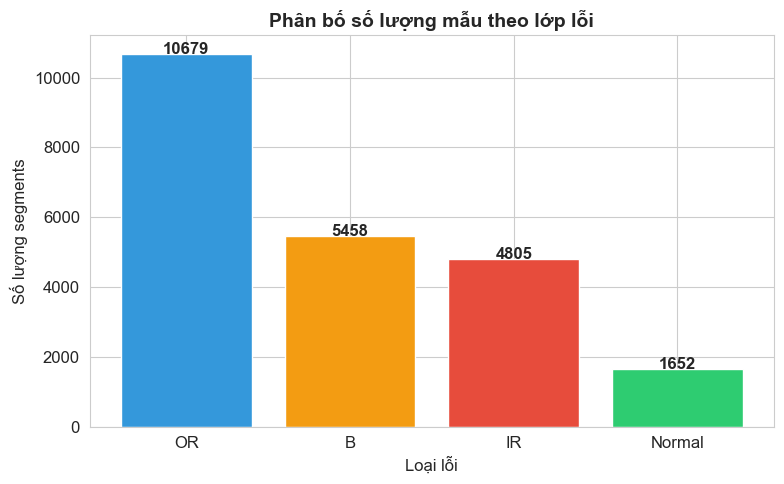

In [23]:
print("⏳ Đang trích đặc trưng cho tất cả segments...")
print(f"   Tổng số segments: {len(X_raw)}")

feature_list = []
for i, seg in enumerate(X_raw):
    feature_list.append(extract_features(seg))
    if (i+1) % 1000 == 0:
        print(f"   Đã xử lý {i+1}/{len(X_raw)} segments...")

X_features = pd.DataFrame(feature_list)
y_labels = pd.Series(y_raw, name='fault_type')

print(f"\n✅ HOÀN TẤT!")
print(f"   X_features shape: {X_features.shape}")
print(f"   Số đặc trưng: {X_features.shape[1]}")
print(f"\n📊 Phân bố lớp:")
print(y_labels.value_counts())

# Vẽ biểu đồ phân bố lớp
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Normal': '#2ecc71', 'IR': '#e74c3c', 'OR': '#3498db', 'B': '#f39c12'}
counts = y_labels.value_counts()
bars = ax.bar(counts.index, counts.values, color=[colors.get(c, '#95a5a6') for c in counts.index])
ax.set_title('Phân bố số lượng mẫu theo lớp lỗi', fontsize=14, fontweight='bold')
ax.set_xlabel('Loại lỗi')
ax.set_ylabel('Số lượng segments')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Khám phá dữ liệu (EDA) & Trực quan hóa

### 4.1. Dạng sóng, phổ FFT và Spectrogram

Chọn ngẫu nhiên 1 segment từ mỗi lớp lỗi và vẽ:
- **Waveform** (trục thời gian): nhìn biên độ và dạng xung
- **FFT** (trục tần số): nhìn năng lượng tập trung ở tần số nào
- **Spectrogram** (thời gian × tần số): nhìn sự thay đổi năng lượng theo thời gian

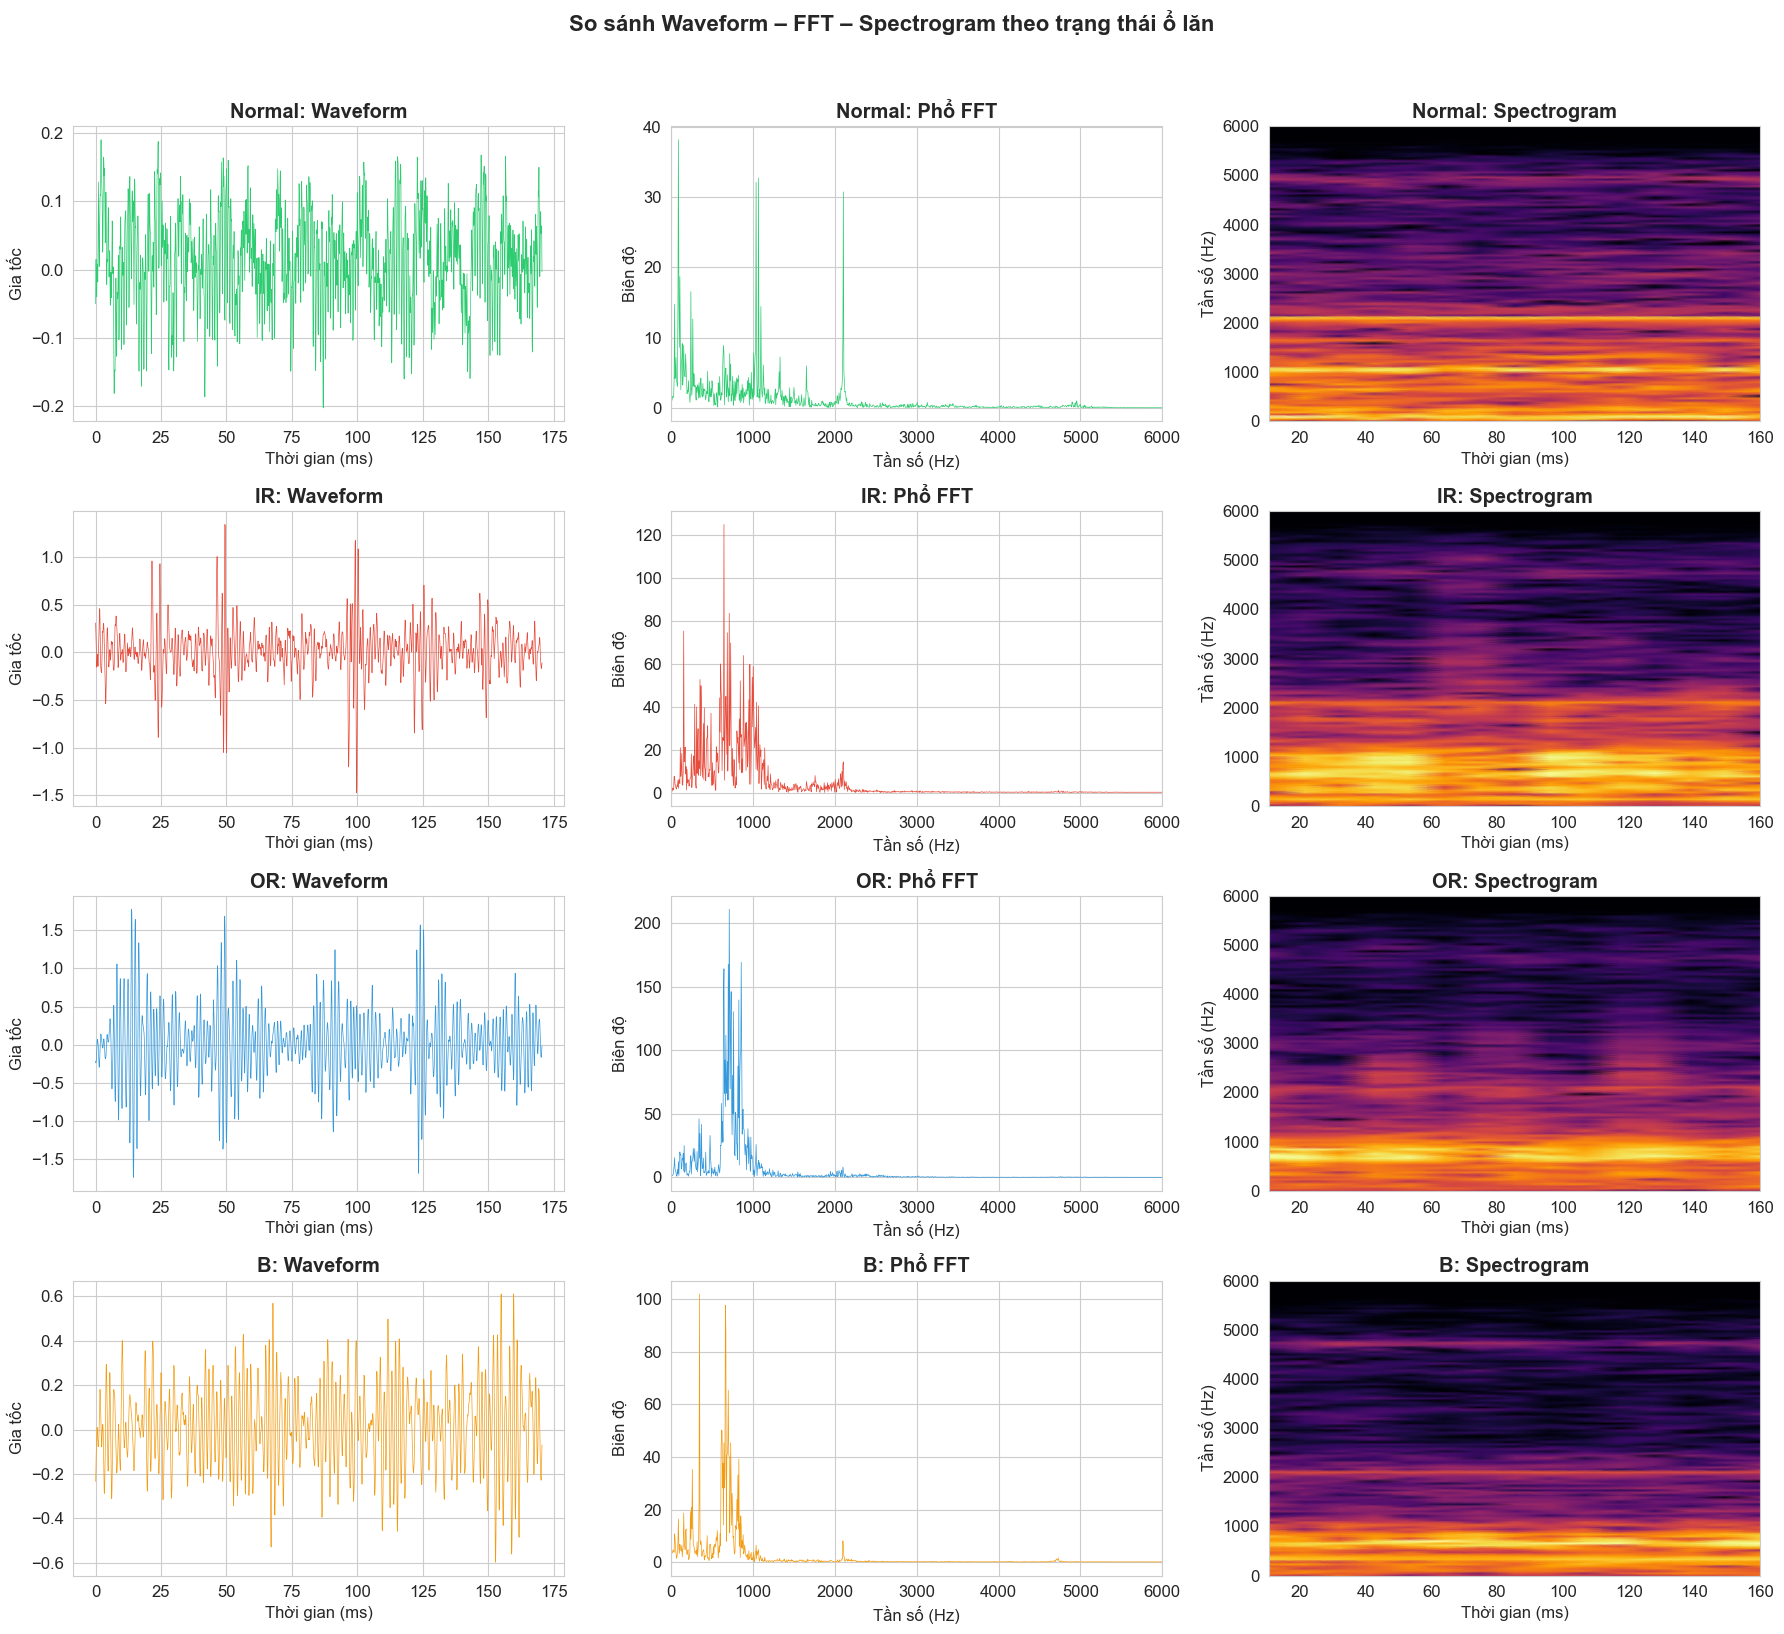


📖 CÁCH ĐỌC:
   Normal: Bình thường - Rung nền đều, biên độ thấp
   IR: Lỗi rãnh trong - Xung lặp lại, biên độ thay đổi (điều biên)
   OR: Lỗi rãnh ngoài - Xung lặp đều đặn, biên độ ổn định
   B: Lỗi bi - Xung phức tạp, biên độ nhỏ hơn IR/OR


In [24]:
# Chọn 1 segment điển hình từ mỗi lớp
class_names = ['Normal', 'IR', 'OR', 'B']
class_colors = {'Normal': '#2ecc71', 'IR': '#e74c3c', 'OR': '#3498db', 'B': '#f39c12'}
class_descriptions = {
    'Normal': 'Bình thường - Rung nền đều, biên độ thấp',
    'IR': 'Lỗi rãnh trong - Xung lặp lại, biên độ thay đổi (điều biên)',
    'OR': 'Lỗi rãnh ngoài - Xung lặp đều đặn, biên độ ổn định',
    'B': 'Lỗi bi - Xung phức tạp, biên độ nhỏ hơn IR/OR'
}

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('So sánh Waveform – FFT – Spectrogram theo trạng thái ổ lăn',
             fontsize=16, fontweight='bold', y=1.02)

for row, cls in enumerate(class_names):
    # Chọn ngẫu nhiên 1 segment của lớp này
    idx = np.where(y_raw == cls)[0]
    chosen = np.random.choice(idx)
    seg = X_raw[chosen]
    
    # --- Waveform ---
    t = np.arange(len(seg)) / SAMPLE_RATE * 1000  # ms
    axes[row, 0].plot(t, seg, color=class_colors[cls], linewidth=0.5)
    axes[row, 0].set_title(f'{cls}: Waveform', fontweight='bold')
    axes[row, 0].set_xlabel('Thời gian (ms)')
    axes[row, 0].set_ylabel('Gia tốc')
    
    # --- FFT ---
    n = len(seg)
    yf = np.abs(fft(seg)[:n//2])
    freqs = fftfreq(n, 1/SAMPLE_RATE)[:n//2]
    axes[row, 1].plot(freqs, yf, color=class_colors[cls], linewidth=0.5)
    axes[row, 1].set_title(f'{cls}: Phổ FFT', fontweight='bold')
    axes[row, 1].set_xlabel('Tần số (Hz)')
    axes[row, 1].set_ylabel('Biên độ')
    axes[row, 1].set_xlim([0, 6000])
    
    # --- Spectrogram ---
    f_spec, t_spec, Sxx = scipy_spectrogram(seg, fs=SAMPLE_RATE, nperseg=256, noverlap=128)
    axes[row, 2].pcolormesh(t_spec*1000, f_spec, 10*np.log10(Sxx+1e-10),
                            shading='gouraud', cmap='inferno')
    axes[row, 2].set_title(f'{cls}: Spectrogram', fontweight='bold')
    axes[row, 2].set_xlabel('Thời gian (ms)')
    axes[row, 2].set_ylabel('Tần số (Hz)')
    axes[row, 2].set_ylim([0, 6000])

plt.tight_layout()
plt.show()

print("\n📖 CÁCH ĐỌC:")
for cls, desc in class_descriptions.items():
    print(f"   {cls}: {desc}")

### 4.2. Boxplot các đặc trưng thống kê theo lớp lỗi

Boxplot giúp so sánh **phân bố** từng đặc trưng giữa các lớp:
- **Hộp tách biệt** → mô hình dễ phân loại
- **Hộp chồng lấp** → mô hình có thể nhầm lẫn

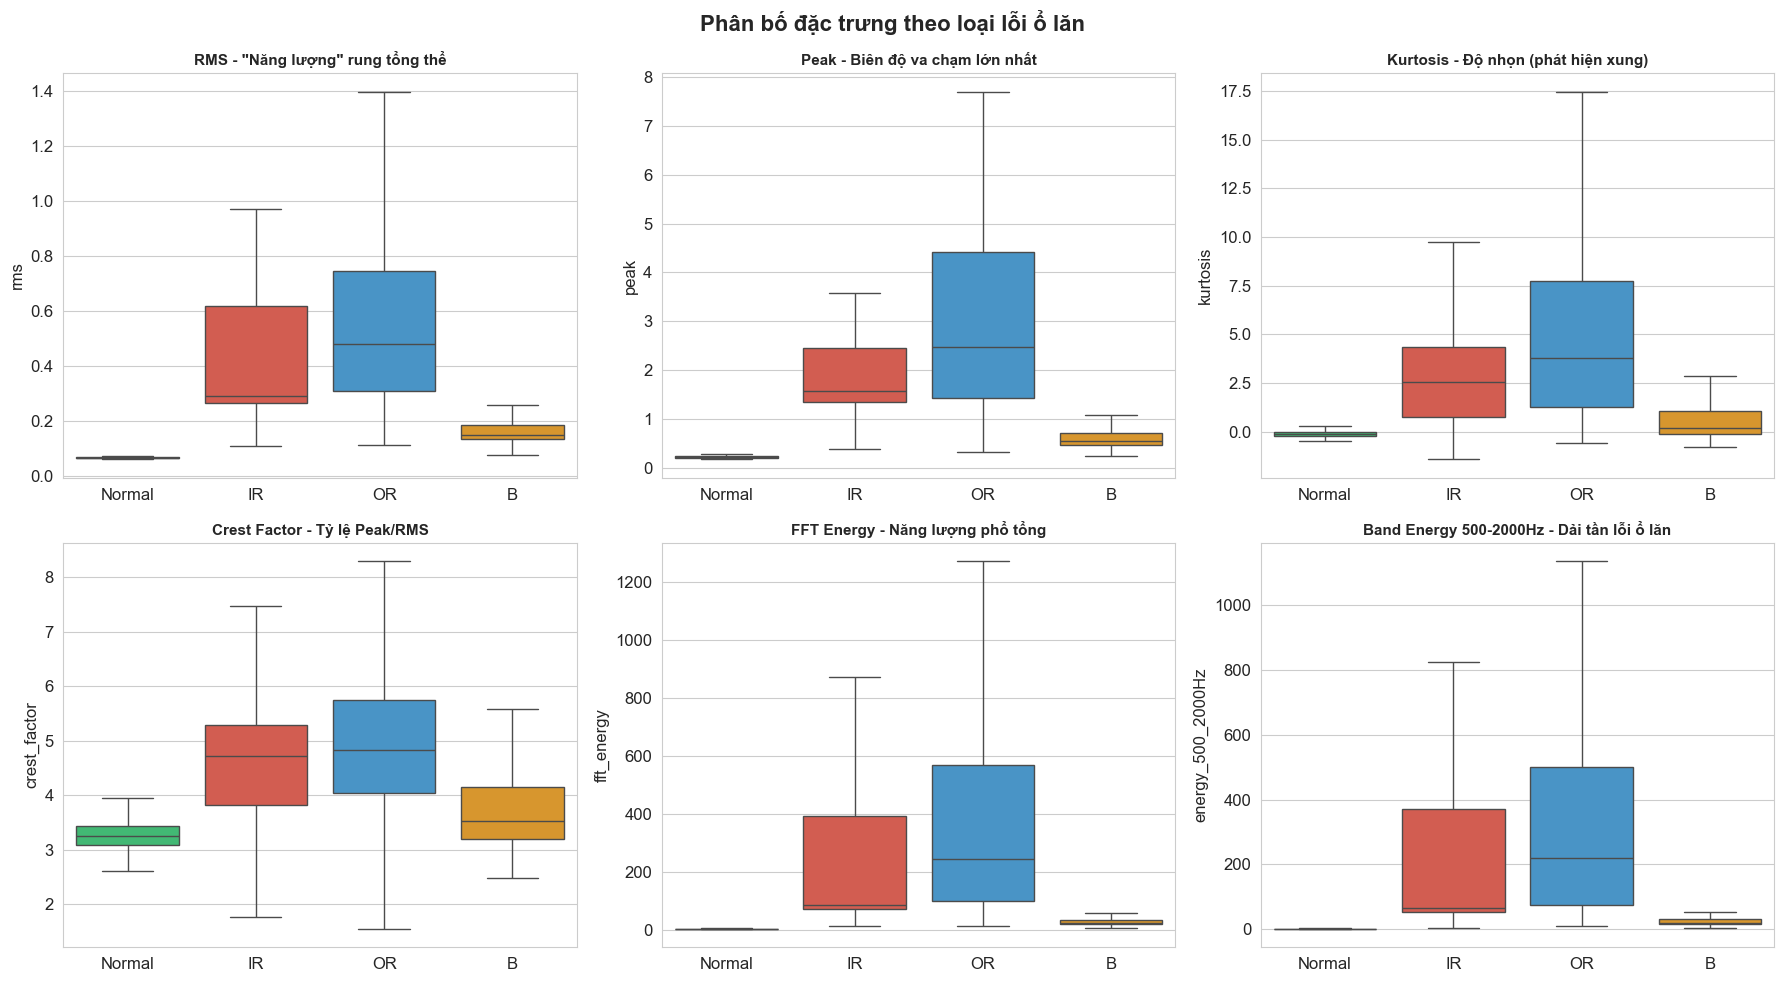


📖 NHẬN XÉT CHO KỸ SƯ:
   • RMS & Peak: tăng rõ rệt khi có lỗi → chỉ số giám sát online tốt
   • Kurtosis: rất nhạy với xung va chạm → 'công cụ phát hiện sớm'
   • Band Energy 500-2000Hz: năng lượng ở dải tần lỗi ổ lăn tăng → xác nhận vị trí lỗi


In [25]:
# Chọn các đặc trưng quan trọng nhất để vẽ
key_features = ['rms', 'peak', 'kurtosis', 'crest_factor', 'fft_energy', 'energy_500_2000Hz']
feature_descriptions = {
    'rms': 'RMS - "Năng lượng" rung tổng thể',
    'peak': 'Peak - Biên độ va chạm lớn nhất',
    'kurtosis': 'Kurtosis - Độ nhọn (phát hiện xung)',
    'crest_factor': 'Crest Factor - Tỷ lệ Peak/RMS',
    'fft_energy': 'FFT Energy - Năng lượng phổ tổng',
    'energy_500_2000Hz': 'Band Energy 500-2000Hz - Dải tần lỗi ổ lăn'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phân bố đặc trưng theo loại lỗi ổ lăn', fontsize=16, fontweight='bold')

plot_df = X_features.copy()
plot_df['fault_type'] = y_labels.values

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    palette = [class_colors[c] for c in class_names if c in plot_df['fault_type'].unique()]
    sns.boxplot(data=plot_df, x='fault_type', y=feat, ax=ax,
                order=class_names, palette=class_colors, showfliers=False)
    ax.set_title(feature_descriptions.get(feat, feat), fontweight='bold', fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print("\n📖 NHẬN XÉT CHO KỸ SƯ:")
print("   • RMS & Peak: tăng rõ rệt khi có lỗi → chỉ số giám sát online tốt")
print("   • Kurtosis: rất nhạy với xung va chạm → 'công cụ phát hiện sớm'")
print("   • Band Energy 500-2000Hz: năng lượng ở dải tần lỗi ổ lăn tăng → xác nhận vị trí lỗi")

## 5. Chia dữ liệu: Train / Validation / Test

Chia 2 lần:
1. **Train+Val (70%)** vs **Test (30%)** – stratify theo lớp
2. Trong Train+Val: **Train (80%)** vs **Val (20%)**

> ⚠️ Dùng `stratify` để đảm bảo tỷ lệ các lớp lỗi giống nhau ở mỗi tập.

In [26]:
# Encode nhãn thành số
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
class_names_encoded = list(le.classes_)
print(f"Nhãn: {dict(zip(class_names_encoded, le.transform(class_names_encoded)))}")

# Chia lần 1: Train+Val (70%) vs Test (30%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_features, y_encoded, test_size=0.3, random_state=RANDOM_SEED, stratify=y_encoded
)

# Chia lần 2: Train (80%) vs Val (20%) trong tập Train+Val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_SEED, stratify=y_trainval
)

print(f"\n📊 Kích thước các tập dữ liệu:")
print(f"   Train:      {X_train.shape[0]:>6} mẫu ({X_train.shape[0]/len(X_features)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]:>6} mẫu ({X_val.shape[0]/len(X_features)*100:.1f}%)")
print(f"   Test:       {X_test.shape[0]:>6} mẫu ({X_test.shape[0]/len(X_features)*100:.1f}%)")

print(f"\n📊 Phân bố lớp trong tập Test:")
for i, cls in enumerate(class_names_encoded):
    cnt = np.sum(y_test == i)
    print(f"   {cls}: {cnt} ({cnt/len(y_test)*100:.1f}%)")

Nhãn: {'B': np.int64(0), 'IR': np.int64(1), 'Normal': np.int64(2), 'OR': np.int64(3)}

📊 Kích thước các tập dữ liệu:
   Train:       12652 mẫu (56.0%)
   Validation:   3163 mẫu (14.0%)
   Test:         6779 mẫu (30.0%)

📊 Phân bố lớp trong tập Test:
   B: 1637 (24.1%)
   IR: 1442 (21.3%)
   Normal: 496 (7.3%)
   OR: 3204 (47.3%)


## 6. Huấn luyện mô hình SVM

### Pipeline: StandardScaler → SVC (RBF kernel)

SVM nhạy cảm với scale dữ liệu → **luôn** dùng StandardScaler trước.

Dùng **GridSearchCV** để tìm tham số tối ưu:
- `C` (regularization): [0.1, 1, 10, 100]
- `gamma` (RBF bandwidth): ['scale', 'auto', 0.01, 0.1]

In [27]:
print("⏳ Đang huấn luyện SVM với GridSearchCV...")
print("   Tìm kiếm tham số tối ưu (C, gamma)...")

# Tạo pipeline: chuẩn hóa → SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED))
])

# Grid search trên tập train+val
param_grid_svm = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svm = GridSearchCV(
    svm_pipeline, param_grid_svm,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Dùng tất cả CPU
    verbose=0
)

# Fit trên toàn bộ train+val
grid_svm.fit(X_trainval, y_trainval)

print(f"\n✅ SVM HOÀN TẤT!")
print(f"   Best params: {grid_svm.best_params_}")
print(f"   Best CV accuracy: {grid_svm.best_score_:.4f}")

# Lưu mô hình tốt nhất
svm_clf = grid_svm.best_estimator_

⏳ Đang huấn luyện SVM với GridSearchCV...
   Tìm kiếm tham số tối ưu (C, gamma)...

✅ SVM HOÀN TẤT!
   Best params: {'svc__C': 100, 'svc__gamma': 0.1}
   Best CV accuracy: 0.9352


### Đánh giá SVM trên tập Test

🎯 SVM Accuracy trên Test: 0.9413 (94.13%)

📋 Classification Report:
              precision    recall  f1-score   support

           B       0.86      0.94      0.90      1637
          IR       0.97      0.95      0.96      1442
      Normal       1.00      1.00      1.00       496
          OR       0.96      0.93      0.95      3204

    accuracy                           0.94      6779
   macro avg       0.95      0.95      0.95      6779
weighted avg       0.94      0.94      0.94      6779



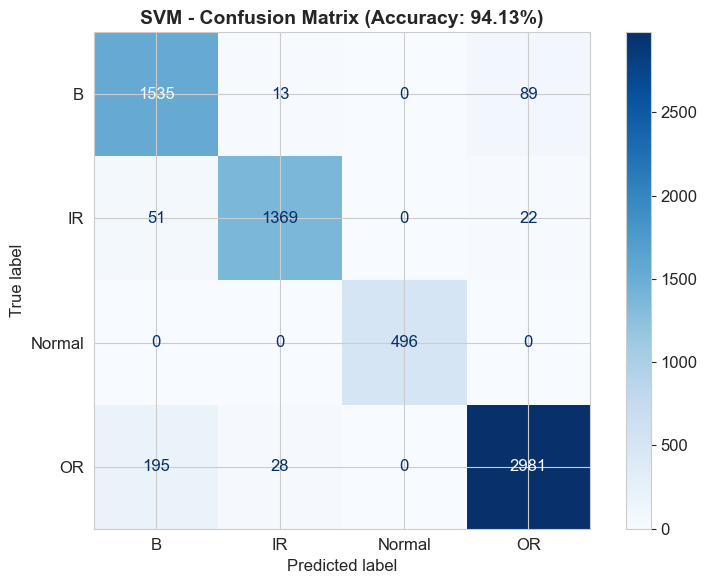

In [28]:
# Dự đoán trên tập test
y_pred_svm = svm_clf.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"🎯 SVM Accuracy trên Test: {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=class_names_encoded))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=class_names_encoded)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'SVM - Confusion Matrix (Accuracy: {acc_svm:.2%})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Huấn luyện mô hình Random Forest

Random Forest = "Rừng nhiều cây quyết định" → biểu quyết đa số.

Tìm tham số tối ưu:
- `n_estimators`: số cây [100, 200, 300]
- `max_depth`: chiều sâu tối đa [10, 20, None]
- `max_features`: số feature xét mỗi node ['sqrt', 'log2']

In [29]:
print("⏳ Đang huấn luyện Random Forest với GridSearchCV...")

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, None],
    'rf__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    rf_pipeline, param_grid_rf,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=0
)

grid_rf.fit(X_trainval, y_trainval)

print(f"\n✅ RANDOM FOREST HOÀN TẤT!")
print(f"   Best params: {grid_rf.best_params_}")
print(f"   Best CV accuracy: {grid_rf.best_score_:.4f}")

rf_model = grid_rf.best_estimator_

⏳ Đang huấn luyện Random Forest với GridSearchCV...

✅ RANDOM FOREST HOÀN TẤT!
   Best params: {'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__n_estimators': 300}
   Best CV accuracy: 0.9730


### Đánh giá Random Forest trên tập Test

🎯 Random Forest Accuracy trên Test: 0.9757 (97.57%)

📋 Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.95      0.96      1637
          IR       0.99      0.98      0.98      1442
      Normal       1.00      1.00      1.00       496
          OR       0.97      0.98      0.98      3204

    accuracy                           0.98      6779
   macro avg       0.98      0.98      0.98      6779
weighted avg       0.98      0.98      0.98      6779



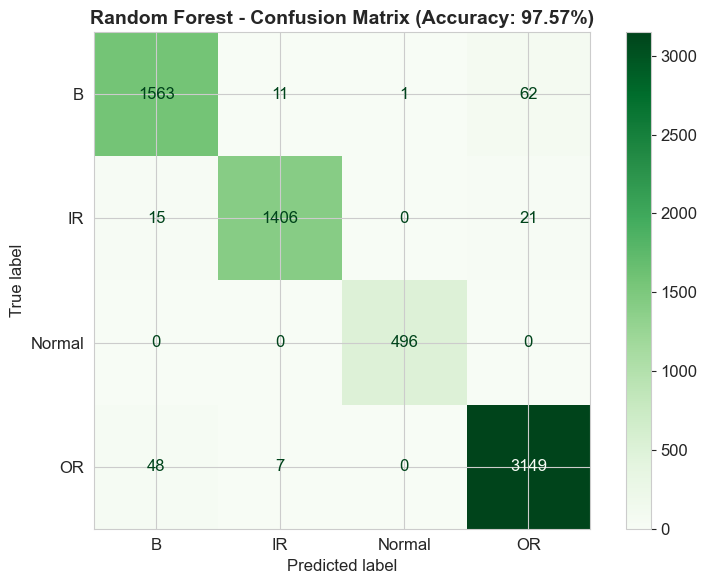

In [30]:
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"🎯 Random Forest Accuracy trên Test: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names_encoded))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=class_names_encoded)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'Random Forest - Confusion Matrix (Accuracy: {acc_rf:.2%})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance từ Random Forest

Random Forest cho biết đặc trưng nào **ảnh hưởng nhiều nhất** đến phân loại. Kỹ sư có thể dùng thông tin này để ưu tiên giám sát.

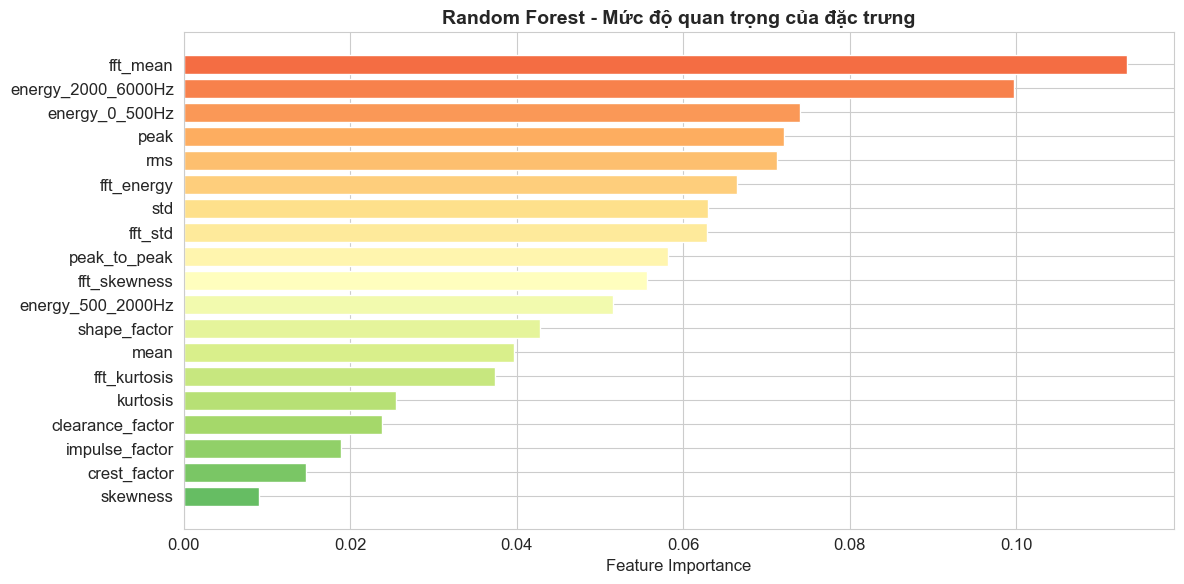


📊 Top 5 đặc trưng quan trọng nhất:
   1. fft_mean                 : 0.1133
   2. energy_2000_6000Hz       : 0.0998
   3. energy_0_500Hz           : 0.0740
   4. peak                     : 0.0722
   5. rms                      : 0.0712


In [31]:
# Lấy feature importance từ RF (bên trong pipeline, sau scaler)
rf_estimator = rf_model.named_steps['rf']
importances = rf_estimator.feature_importances_
feat_names = X_features.columns

# Sắp xếp theo importance giảm dần
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_names)))
ax.barh(range(len(feat_names)), importances[sorted_idx[::-1]], color=colors)
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names[sorted_idx[::-1]])
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest - Mức độ quan trọng của đặc trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 đặc trưng quan trọng nhất:")
for i in range(min(5, len(feat_names))):
    print(f"   {i+1}. {feat_names[sorted_idx[i]]:25s}: {importances[sorted_idx[i]]:.4f}")

## 8. So sánh SVM vs Random Forest

| Tiêu chí | SVM | Random Forest |
|---|---|---|
| Accuracy | Xem bên dưới | Xem bên dưới |
| Khả năng giải thích | Khó (kernel space) | Tốt (feature importance) |
| Tốc độ SHAP | Chậm (KernelExplainer) | Nhanh (TreeExplainer) |

In [32]:
print("=" * 60)
print("          SO SÁNH SVM vs RANDOM FOREST")
print("=" * 60)
print(f"{'Tiêu chí':<25} {'SVM':>15} {'Random Forest':>15}")
print("-" * 60)
print(f"{'Accuracy (Test)':<25} {acc_svm:>14.2%} {acc_rf:>14.2%}")
print(f"{'Best CV Score':<25} {grid_svm.best_score_:>14.4f} {grid_rf.best_score_:>14.4f}")
print(f"{'Giải thích (SHAP)':<25} {'KernelExplainer':>15} {'TreeExplainer':>15}")
print(f"{'Tốc độ SHAP':<25} {'Chậm':>15} {'Rất nhanh':>15}")
print("-" * 60)
winner = "SVM" if acc_svm > acc_rf else "Random Forest" if acc_rf > acc_svm else "Hòa"
print(f"\n🏆 Mô hình tốt hơn trên tập test: {winner}")
print("\n💡 Nhận xét: Cả hai mô hình đều cho kết quả rất tốt trên CWRU.")
print("   Random Forest thường được ưu tiên vì dễ giải thích hơn với SHAP.")

          SO SÁNH SVM vs RANDOM FOREST
Tiêu chí                              SVM   Random Forest
------------------------------------------------------------
Accuracy (Test)                   94.13%         97.57%
Best CV Score                     0.9352         0.9730
Giải thích (SHAP)         KernelExplainer   TreeExplainer
Tốc độ SHAP                          Chậm       Rất nhanh
------------------------------------------------------------

🏆 Mô hình tốt hơn trên tập test: Random Forest

💡 Nhận xét: Cả hai mô hình đều cho kết quả rất tốt trên CWRU.
   Random Forest thường được ưu tiên vì dễ giải thích hơn với SHAP.


## 9. Giải thích mô hình bằng SHAP

### 9.1. SHAP cho Random Forest (TreeExplainer - nhanh)

SHAP (SHapley Additive exPlanations) cho biết **từng đặc trưng đóng góp bao nhiêu** vào dự đoán.

- **SHAP value dương** → đẩy dự đoán về phía lớp đang xét
- **SHAP value âm** → kéo dự đoán khỏi lớp đó

In [33]:
print("\u23f3 \u0110ang t\u00ednh SHAP values cho Random Forest...")

# Chu\u1ea9n b\u1ecb d\u1eef li\u1ec7u: scale gi\u1ed1ng l\u00fac train
scaler_rf = rf_model.named_steps['scaler']
rf_est = rf_model.named_steps['rf']

X_test_scaled = scaler_rf.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_features.columns)

# TreeExplainer - r\u1ea5t nhanh cho Random Forest
explainer_rf = shap.TreeExplainer(rf_est)

# T\u00ednh SHAP cho 200 m\u1eabu test (\u0111\u1ee7 \u0111\u1ec3 th\u1ea5y xu h\u01b0\u1edbng)
n_explain = min(200, len(X_test_df))
shap_values_raw = explainer_rf.shap_values(X_test_df.iloc[:n_explain])

# X\u1eed l\u00fd c\u1ea5u tr\u00fac SHAP values (t\u01b0\u01a1ng th\u00edch c\u1ea3 phi\u00ean b\u1ea3n c\u0169 v\u00e0 m\u1edbi)
# Phi\u00ean b\u1ea3n c\u0169: list c\u1ee7a arrays, m\u1ed7i array shape (n_samples, n_features)
# Phi\u00ean b\u1ea3n m\u1edbi: 3D array shape (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    # Format c\u0169: list c\u1ee7a arrays
    shap_values_rf = shap_values_raw
    print(f"SHAP format: list of {len(shap_values_rf)} arrays, m\u1ed7i array shape {shap_values_rf[0].shape}")
else:
    shap_values_raw = np.array(shap_values_raw)
    if shap_values_raw.ndim == 3:
        # Format m\u1edbi: (n_samples, n_features, n_classes) -> chuy\u1ec3n th\u00e0nh list
        n_classes = shap_values_raw.shape[2]
        shap_values_rf = [shap_values_raw[:, :, c] for c in range(n_classes)]
        print(f"SHAP format: 3D array -> chuy\u1ec3n th\u00e0nh list c\u1ee7a {n_classes} arrays")
    else:
        # Binary hoặc single output
        shap_values_rf = [shap_values_raw]
        print(f"SHAP format: single array shape {shap_values_raw.shape}")

print(f"\u2705 \u0110\u00e3 t\u00ednh SHAP values cho {n_explain} m\u1eabu test.")
print(f"   S\u1ed1 l\u1edbp: {len(shap_values_rf)}")
print(f"   Shape m\u1ed7i l\u1edbp: {shap_values_rf[0].shape}")


⏳ Đang tính SHAP values cho Random Forest...
SHAP format: 3D array -> chuyển thành list của 4 arrays
✅ Đã tính SHAP values cho 200 mẫu test.
   Số lớp: 4
   Shape mỗi lớp: (200, 19)


### 9.2. Summary Plot – Tổng quan ảnh hưởng của đặc trưng

**Cách đọc:**
- Mỗi hàng = 1 đặc trưng (sắp xếp theo mức quan trọng)
- Mỗi chấm = 1 mẫu test
- 🔴 Đỏ = giá trị feature CAO, 🔵 Xanh = giá trị feature THẤP
- Trục X: SHAP value (dương = tăng xác suất lớp, âm = giảm)

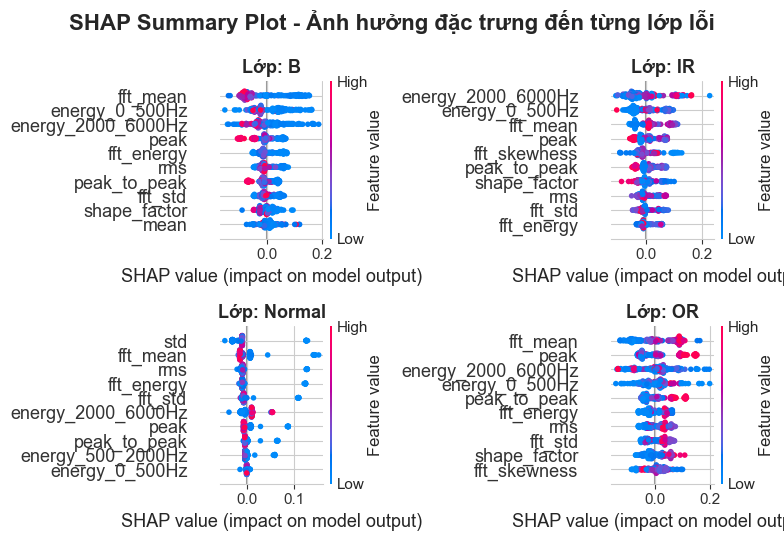


📖 CÁCH ĐỌc SUMMARY PLOT:
   • Feature ở trên cùng = quan trọng nhất cho lớp đó
   • Chấm đỏ bên phải = giá trị feature CAO → TĂNG xác suất lớp
   • Chấm xanh bên phải = giá trị feature THẤP → TĂNG xác suất lớp


In [34]:
# Summary plot cho t\u1eebng l\u1edbp
n_shap_classes = len(shap_values_rf)
n_plot_classes = min(n_shap_classes, len(class_names_encoded))

if n_plot_classes <= 2:
    fig, axes = plt.subplots(1, n_plot_classes, figsize=(9*n_plot_classes, 6))
    if n_plot_classes == 1:
        axes = np.array([axes])
else:
    n_rows = (n_plot_classes + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 7*n_rows))
    axes = axes.flatten()

fig.suptitle('SHAP Summary Plot - \u1ea2nh h\u01b0\u1edfng \u0111\u1eb7c tr\u01b0ng \u0111\u1ebfn t\u1eebng l\u1edbp l\u1ed7i',
             fontsize=16, fontweight='bold')

for idx in range(n_plot_classes):
    cls = class_names_encoded[idx]
    plt.sca(axes[idx])
    shap.summary_plot(shap_values_rf[idx], X_test_df.iloc[:n_explain],
                      show=False, max_display=10)
    plt.title(f'L\u1edbp: {cls}', fontsize=13, fontweight='bold')

# \u1ea8n b\u1edbt axes th\u1eeba n\u1ebfu c\u00f3
if n_plot_classes > 2:
    for idx in range(n_plot_classes, len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("\n\U0001f4d6 C\u00c1CH \u0110\u1eccc SUMMARY PLOT:")
print("   \u2022 Feature \u1edf tr\u00ean c\u00f9ng = quan tr\u1ecdng nh\u1ea5t cho l\u1edbp \u0111\u00f3")
print("   \u2022 Ch\u1ea5m \u0111\u1ecf b\u00ean ph\u1ea3i = gi\u00e1 tr\u1ecb feature CAO \u2192 T\u0102NG x\u00e1c su\u1ea5t l\u1edbp")
print("   \u2022 Ch\u1ea5m xanh b\u00ean ph\u1ea3i = gi\u00e1 tr\u1ecb feature TH\u1ea4P \u2192 T\u0102NG x\u00e1c su\u1ea5t l\u1edbp")


### 9.3. Bar Plot – Feature Importance tổng thể từ SHAP

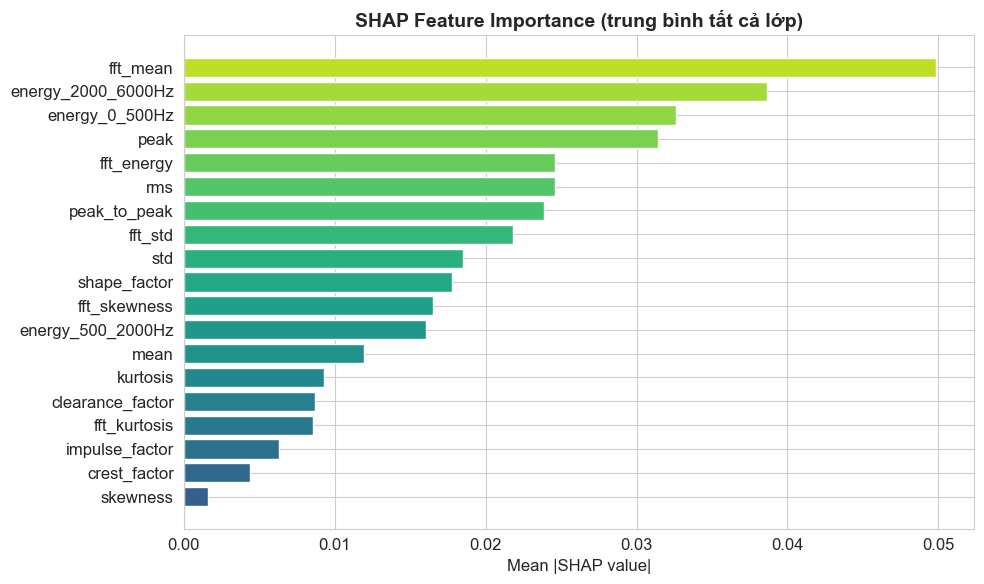


📊 Top 5 đặc trưng quan trọng nhất theo SHAP:
   1. fft_mean                 : 0.0499
   2. energy_2000_6000Hz       : 0.0386
   3. energy_0_500Hz           : 0.0326
   4. peak                     : 0.0314
   5. fft_energy               : 0.0246


In [35]:
# Bar plot tổng hợp (trung bình |SHAP| qua tất cả lớp)
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_rf], axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(mean_abs_shap)), mean_abs_shap[sorted_idx[::-1]],
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(mean_abs_shap))))
ax.set_yticks(range(len(mean_abs_shap)))
ax.set_yticklabels(X_features.columns[sorted_idx[::-1]])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance (trung bình tất cả lớp)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 đặc trưng quan trọng nhất theo SHAP:")
for i in range(min(5, len(mean_abs_shap))):
    print(f"   {i+1}. {X_features.columns[sorted_idx[i]]:25s}: {mean_abs_shap[sorted_idx[i]]:.4f}")

### 9.4. Waterfall Plot – Giải thích từng mẫu cụ thể

Chọn 1 mẫu từ mỗi lớp và vẽ waterfall plot – cho thấy "câu chuyện chẩn đoán":
- Bắt đầu từ **base value** (dự đoán trung bình)
- Cộng/trừ đóng góp của từng feature
- → Kết quả dự đoán cuối cùng

  WATERFALL PLOT - GIẢI THÍCH TỮNG MẪu CỤ THỂ

──────────────────────────────────────────────────────────────────────
📋 Mẫu B (index=4)
   Nhãn thật: B | Dự đoán: B


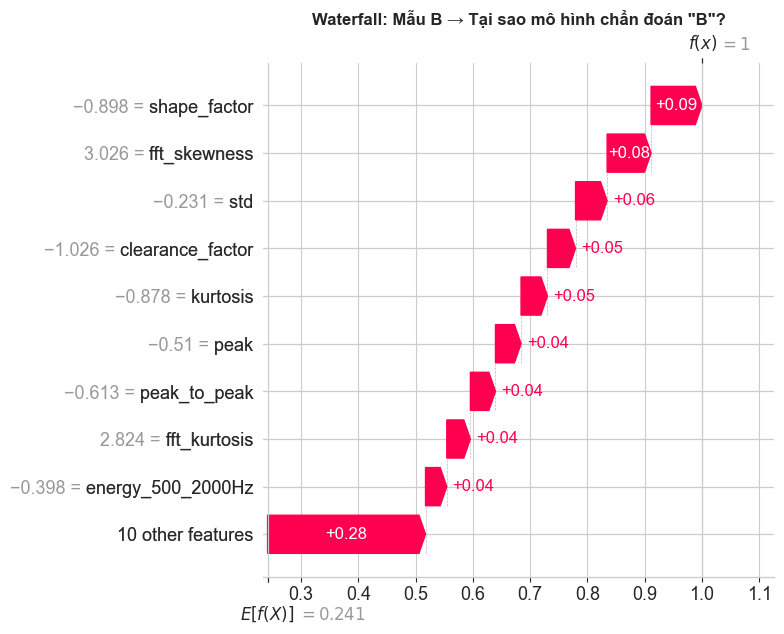


──────────────────────────────────────────────────────────────────────
📋 Mẫu IR (index=3)
   Nhãn thật: IR | Dự đoán: IR


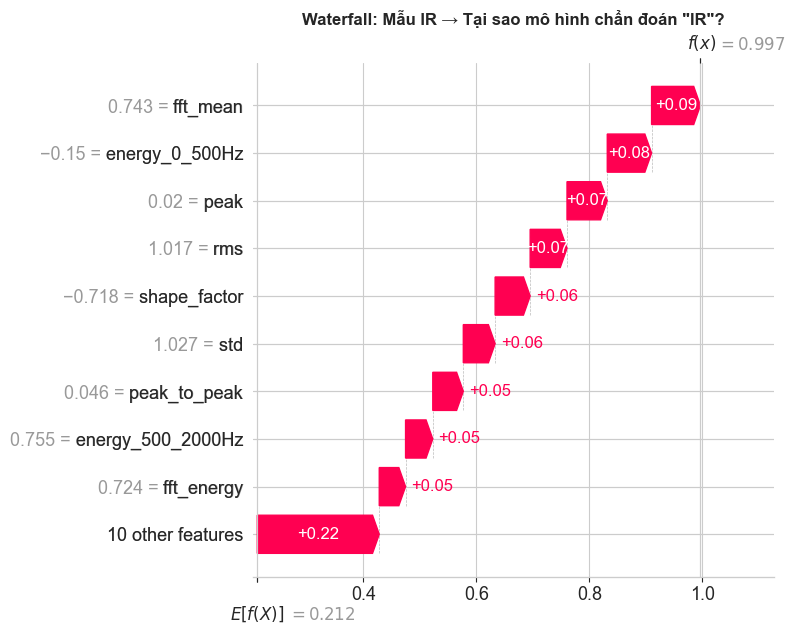


──────────────────────────────────────────────────────────────────────
📋 Mẫu Normal (index=2)
   Nhãn thật: Normal | Dự đoán: Normal


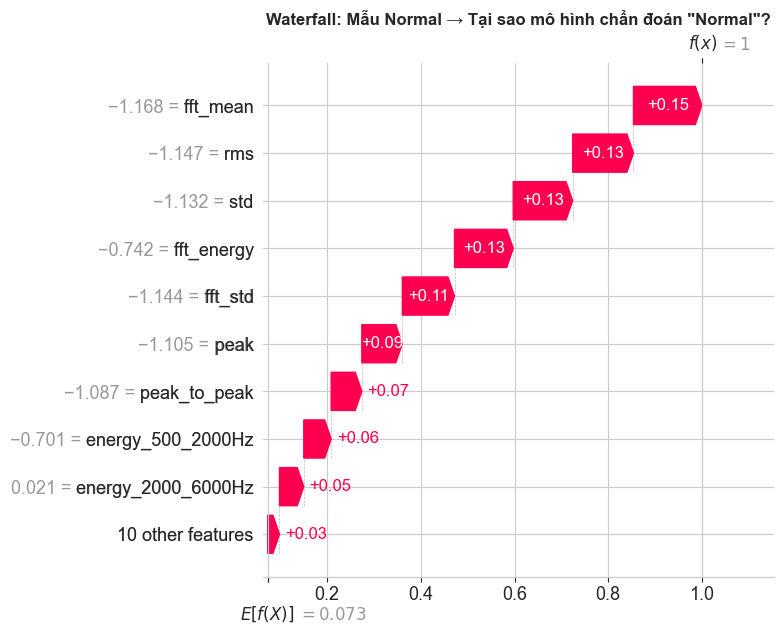


──────────────────────────────────────────────────────────────────────
📋 Mẫu OR (index=0)
   Nhãn thật: OR | Dự đoán: OR


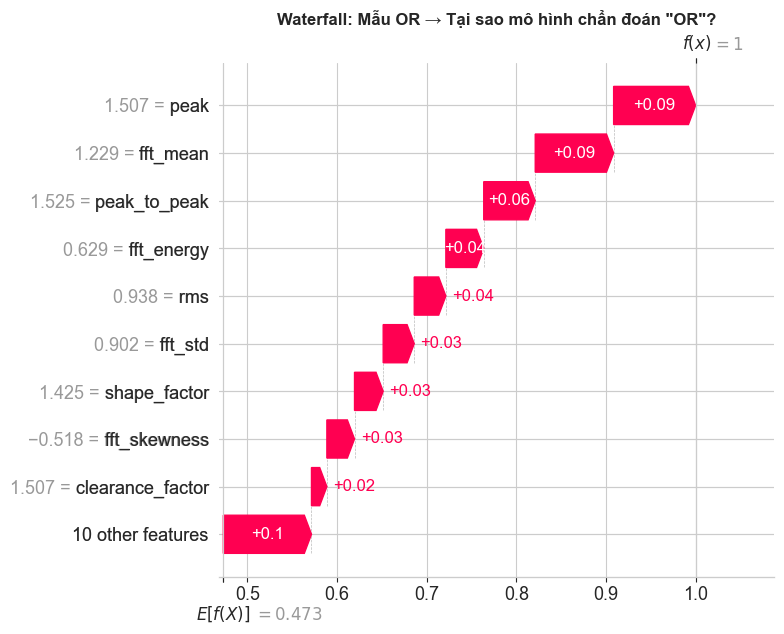


📖 CÁCH ĐỌc WATERFALL PLOT:
   • E[f(x)] = base value (điểm xuất phát, dự đoán trung bình)
   • Thanh ĐỎ (+): feature này TĂNG xác suất lớp đang xét
   • Thanh XANH (−): feature này GIẢM xác suất lớp đang xét
   • f(x) = dự đoán cuối cùng = base + tổng các SHAP values


In [37]:
# Ch\u1ecdn 1 m\u1eabu \u0111\u00fang t\u1eeb m\u1ed7i l\u1edbp
print("=" * 70)
print("  WATERFALL PLOT - GI\u1ea2I TH\u00cdCH T\u1eeeNG M\u1eaau C\u1ee4 TH\u1ec2")
print("=" * 70)

n_shap_classes = len(shap_values_rf)
n_plot_classes = min(n_shap_classes, len(class_names_encoded))

for cls_idx in range(n_plot_classes):
    cls_name = class_names_encoded[cls_idx]
    # T\u00ecm m\u1eabu \u0111\u00fang: m\u00f4 h\u00ecnh d\u1ef1 \u0111o\u00e1n \u0111\u00fang l\u1edbp n\u00e0y
    correct_mask = (y_test[:n_explain] == cls_idx) & (y_pred_rf[:n_explain] == cls_idx)
    correct_indices = np.where(correct_mask)[0]
    
    if len(correct_indices) == 0:
        print(f"\n\u26a0\ufe0f  Kh\u00f4ng t\u00ecm th\u1ea5y m\u1eabu {cls_name} \u0111\u01b0\u1ee3c d\u1ef1 \u0111o\u00e1n \u0111\u00fang")
        continue
    
    sample_idx = correct_indices[0]
    
    sep = '─' * 70
    print(f"\n{sep}")
    print(f"\U0001f4cb M\u1eabu {cls_name} (index={sample_idx})")
    print(f"   Nh\u00e3n th\u1eadt: {cls_name} | D\u1ef1 \u0111o\u00e1n: {class_names_encoded[y_pred_rf[sample_idx]]}")
    
    # L\u1ea5y expected value t\u01b0\u01a1ng th\u00edch
    if hasattr(explainer_rf.expected_value, "__len__"):
        base_val = explainer_rf.expected_value[cls_idx]
    else:
        base_val = explainer_rf.expected_value
    
    # T\u1ea1o SHAP Explanation object
    explanation = shap.Explanation(
        values=shap_values_rf[cls_idx][sample_idx],
        base_values=base_val,
        data=X_test_df.iloc[sample_idx].values,
        feature_names=list(X_features.columns)
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(explanation, show=False, max_display=10)
    plt.title(f'Waterfall: M\u1eabu {cls_name} \u2192 T\u1ea1i sao m\u00f4 h\u00ecnh ch\u1ea9n \u0111o\u00e1n "{cls_name}"?',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n\U0001f4d6 C\u00c1CH \u0110\u1eccc WATERFALL PLOT:")
print("   \u2022 E[f(x)] = base value (\u0111i\u1ec3m xu\u1ea5t ph\u00e1t, d\u1ef1 \u0111o\u00e1n trung b\u00ecnh)")
print("   \u2022 Thanh \u0110\u1ece (+): feature n\u00e0y T\u0102NG x\u00e1c su\u1ea5t l\u1edbp \u0111ang x\u00e9t")
print("   \u2022 Thanh XANH (\u2212): feature n\u00e0y GI\u1ea2M x\u00e1c su\u1ea5t l\u1edbp \u0111ang x\u00e9t")
print("   \u2022 f(x) = d\u1ef1 \u0111o\u00e1n cu\u1ed1i c\u00f9ng = base + t\u1ed5ng c\u00e1c SHAP values")

### 9.5. Hướng dẫn diễn giải SHAP cho kỹ sư hiện trường

**Cách chuyển SHAP thành khuyến nghị bảo trì:**

| SHAP cho thấy | Ý nghĩa thực tế | Hành động |
|---|---|---|
| RMS cao + SHAP dương lớn | Rung tổng thể tăng mạnh | Kiểm tra ngay ổ lăn |
| Kurtosis cao + SHAP dương | Có xung va chạm rõ ràng | Lỗi đã bắt đầu phát triển |
| FFT energy dải BPFI + SHAP dương | Năng lượng ở tần số lỗi rãnh trong | Xác nhận: lỗi rãnh trong |
| Nhiều feature có SHAP nhỏ | Chưa có dấu hiệu rõ ràng | Theo dõi định kỳ |
| SHAP mâu thuẫn (một số +, một số −) | Tín hiệu không rõ ràng | Tăng tần suất đo, kiểm tra lại cảm biến |

**Ví dụ diễn giải:**

> "SHAP cho thấy mẫu này bị phân loại là lỗi rãnh trong (IR) chủ yếu vì:  
> (1) RMS = 3.5 (cao gấp 3 lần bình thường) → rung mạnh  
> (2) Kurtosis = 11 (bình thường ~ 3) → có xung va chạm tuần hoàn  
> (3) Năng lượng dải 500-2000Hz cao → tần số lỗi rãnh trong hoạt động  
>  
> **Khuyến nghị:** Thay ổ lăn trong lần dừng máy gần nhất. Nếu không thể dừng ngay, tăng tần suất giám sát lên hàng ngày."


## 10. Kết luận & Gợi ý mở rộng

### Pipeline hoàn chỉnh mà kỹ sư có thể áp dụng

```
1. Thu thập dữ liệu rung (accelerometer) → file .csv / .mat / .tdms
2. Cắt segment (window 2048-4096, overlap 50%)
3. Trích đặc trưng (RMS, kurtosis, peak, FFT energy, band energy)
4. Huấn luyện mô hình (Random Forest khuyến nghị cho lần đầu)
5. Đánh giá (accuracy, confusion matrix, classification report)
6. Giải thích bằng SHAP (summary plot + waterfall plot)
7. Chuyển kết quả SHAP thành khuyến nghị bảo trì
```

### 🎯 Bài tập cho học viên

1. **Thay đổi kích thước cửa sổ:** Thử `WINDOW_SIZE = 4096` hoặc `1024`. Accuracy thay đổi thế nào? Feature importance có đổi không?

2. **Chỉ dùng feature miền thời gian:** Bỏ các feature `fft_*` và `energy_*`, chỉ giữ lại feature thời gian. Accuracy giảm bao nhiêu?

3. **So sánh thêm mô hình khác:** Thử thêm Gradient Boosting hoặc XGBoost:
```python
from sklearn.ensemble import GradientBoostingClassifier
# hoặc
from xgboost import XGBClassifier
```

4. **Cross-domain test:** Huấn luyện chỉ trên 0HP, test trên 1HP/2HP/3HP. Accuracy giảm bao nhiêu? → Đây là thách thức thực tế khi áp dụng mô hình từ phòng thí nghiệm sang nhà máy.

5. **Thử với dữ liệu nhà máy:** Nếu có dữ liệu rung từ nhà máy của bạn, thay `DATA_ROOT` và chỉnh `parse_label_from_filename()` → pipeline vẫn hoạt động!